# FMU: Rollback Mechanism

This tutorial introduces the practical rollback behavior of FMI 2.0 co-simulation FMUs exported from Modelica and used in `syssimx`.

The focus is not event handling yet. The goal is to establish whether `snapshot` and `restore` operations are reliable for different FMU solver backends (`euler`, `cvode`), since this is a prerequisite for robust hybrid event localization.


## Overview

We will:

1. Export `Pendulum.mo` as FMI 2.0 co-simulation FMUs (`euler`, `cvode`).
2. Inspect the FMU capability flag `canGetAndSetFMUstate`.
3. Perform a practical two-pass restore test (`t0 -> t1 -> t2`, restore at `t1`, rerun `t1 -> t2`).
4. Compare rollback behavior for Euler and CVode FMUs.
5. Derive implementation implications for `FMUComponent` extensions in later hybrid tutorials.


## Learning Goals

- Understand why rollback-capable components are required for hybrid co-simulation.
- Distinguish formal FMU capability flags from practical runtime behavior.
- Understand solver-dependent restore strategies for Modelica FMUs.
- Prepare the transition to explicit event localization and event handling in subsequent tutorials.


## Prerequisites and Setup

We assume the setup from tutorials 01 and 02:

- OpenModelica + `OMPython`
- `syssimx` environment with `FMUComponent`
- `numpy` and `matplotlib`

Model used here: `Pendulum.mo` (continuous pendulum without internal contact model).


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from OMPython import ModelicaSystem
from syssimx import FMUComponent

## Theory: Rollback for Hybrid FMU Simulation

In hybrid co-simulation, state events can occur inside a macro interval `[t, t+dt]`. To localize event time accurately (e.g., by bisection), the master algorithm needs repeatable rollback operations:

1. save a snapshot at the left boundary,
2. perform trial integration,
3. restore the previous snapshot,
4. repeat until the event time is localized.

Therefore, robust hybrid simulation depends on reliable component methods analogous to `snapshot_state()` and `restore_state()`, not only on event-indicator evaluation.


## Modelica Source Model

We reuse the pendulum model from tutorial 01 (`Pendulum.mo`) to isolate rollback behavior from contact/event-model complexity.

Using a continuous model here keeps the restore test minimal and directly attributable to FMU solver-state behavior.


In [2]:
model_file = Path("docs/tutorials/tool_integration/modelica/Pendulum.mo")

## Export FMUs

We export two FMI 2.0 Co-Simulation FMUs from the same Modelica model:

- `euler`
- `cvode`

This keeps model equations fixed and isolates the influence of solver-internal state handling on rollback behavior.


In [ ]:
def export_fmu(solver: str) -> str:
    model = ModelicaSystem(
        fileName=str(model_file),
        modelName="Pendulum",
        commandLineOptions=[f"--fmiFlags=s:{solver}", "-d=fmuExperimental"],
    )
    model.buildModel()
    temp_path = model.convertMo2Fmu(version="2.0", fmuType="cs")
    temp_path = Path(temp_path)
    dest_path = Path("docs/tutorials/tool_integration/modelica") / ('pendulum_' + f"{solver}.fmu")
    if dest_path.exists():
        dest_path.unlink()
    temp_path.rename(dest_path)
    return str(dest_path)


fmu_paths = {
    "euler": export_fmu("euler"),
    "cvode": export_fmu("cvode"),
}

## Solver-Specific FMU State Capability

The FMI capability flag `canGetAndSetFMUstate` is informative, but hybrid simulation requires a practical verification.

We apply the following restore test:

1. simulate from `t0` to `t1` and store a snapshot,
2. simulate from `t1` to `t2` (first pass),
3. restore the snapshot at `t1`,
4. simulate again from `t1` to `t2` (second pass).

If restore is operational, first and second pass should overlap over `[t1, t2]`.


In [ ]:
comp = FMUComponent(name="PendulumEuler", fmu_path=fmu_paths["euler"])

comp.initialize(t0=0.0)

comp.set_inputs({"torque": 30})

t_interavl = 3
dt = 1e-4
time_points_1 = np.arange(0, t_interavl + dt, dt)
time_points_2 = np.arange(t_interavl, 2 * t_interavl + dt, dt)


for t in time_points_1:
    comp.do_step(t, dt)

t_rollback = t_interavl
state = comp._instance.getFMUState()

for t in time_points_2:
    comp.do_step(t, dt)

t_vals_1, values = comp.get_history_arrays()
comp.history.clear()

comp._instance.setFMUState(state)
comp._apply_parameters_starts() 

comp.set_inputs({"torque": 30})

for t in time_points_2:
    comp.do_step(t, dt)

t_vals_2, values_2 = comp.get_history_arrays()

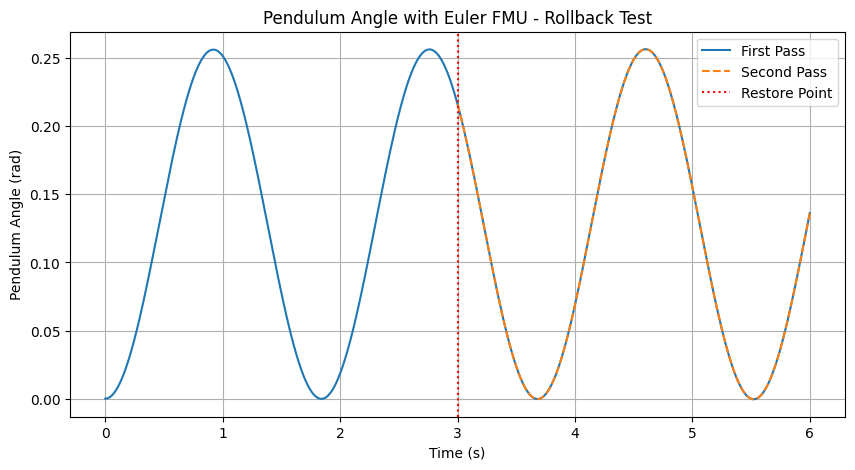

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(t_vals_1, values["theta"], label="First Pass")
plt.plot(t_vals_2, values_2["theta"], label="Second Pass", linestyle="--")
plt.axvline(x=t_interavl, color="red", linestyle=":", label="Restore Point")
plt.xlabel("Time (s)")
plt.ylabel("Pendulum Angle (rad)") 
plt.title("Pendulum Angle with Euler FMU - Rollback Test")
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [6]:
comp = FMUComponent(name="PendulumCvode", fmu_path=fmu_paths["cvode"])

comp.initialize(t0=0.0)

comp.set_inputs({"torque": 30})

t_interavl = 3
dt = 0.001
time_points_1 = np.arange(0, t_interavl + dt, dt)
time_points_2 = np.arange(t_interavl, 2 * t_interavl + dt, dt)


for t in time_points_1:
    comp.do_step(t, dt)

t_rollback = t_interavl
state = comp._instance.getFMUState()


for t in time_points_2:
    comp.do_step(t, dt)

t_vals_1, values = comp.get_history_arrays()
comp.history.clear()

comp._instance.setFMUState(state)
comp._apply_parameters_starts()
comp.set_inputs({"torque": 30})

try:
    for t in time_points_2:
        comp.do_step(t, dt)
except Exception as e:
    print(f"{100 * '='}\nAn error occurred during the second run:\n{e}\n{100 * '='}")
finally:
    print("Requires Reinitialization:")
    print(f"  1) Evaluate state variables theta and omega at the restore point (t={t_rollback} s).")
    print(f"  2) Reset the component and set the initial conditions to the evaluated state variables.")
    print(f"  3) Reinitialize the component and rerun the second pass.\n{100 * '='}")
    state = comp.get_outputs()
    comp.reset()
    comp.set_parameters(**{'theta0': state["theta"],
                           'omega0': state["omega"]})
    comp.initialize(t0=t_rollback)
    comp.set_inputs({"torque": 30})
    for t in time_points_2:
        comp.do_step(t, dt)

t_vals_2, values_2 = comp.get_history_arrays()



LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
An error occurred during the second run:
fmi2DoStep failed with status 4

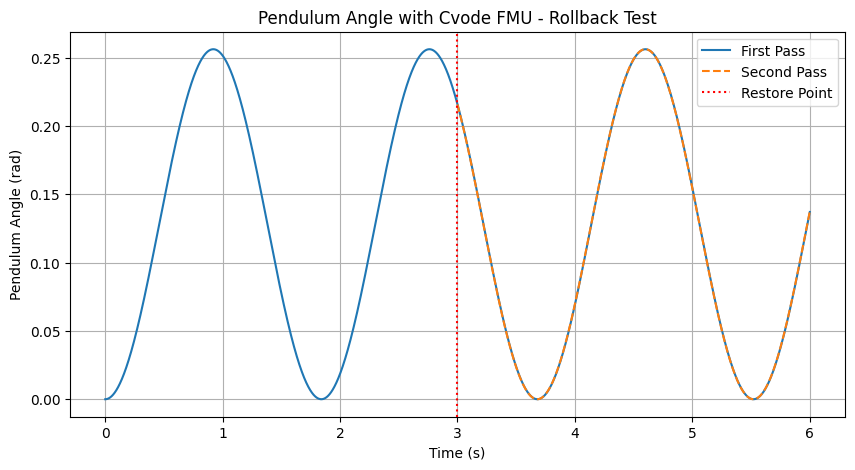

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(t_vals_1, values["theta"], label="First Pass")
plt.plot(t_vals_2, values_2["theta"], label="Second Pass", linestyle="--")
plt.axvline(x=t_interavl, color="red", linestyle=":", label="Restore Point")
plt.xlabel("Time (s)")
plt.ylabel("Pendulum Angle (rad)") 
plt.title("Pendulum Angle with Cvode FMU - Rollback Test")
plt.legend(loc="upper right")
plt.grid()
plt.show()

## Conclusion

This tutorial shows a solver-dependent rollback behavior for Modelica FMUs in co-simulation:

- **Euler FMU**: practical restore via `getFMUState`/`setFMUState` is feasible in this setup.
- **CVode FMU**: direct rollback to earlier communication times is not reliably supported in the same way; reinitialization with reconstructed state is required.

This is the key motivation for the next step in the tutorial sequence: extending `FMUComponent` in `syssimx` with explicit rollback strategy and event-handling logic suitable for hybrid state-event localization.
